In [1]:
import os

os.chdir('..')

## Loading the Dataset:

In this section the pointcloud is loaded. The SIREN paper suggests normalizing the point coordinates as periodic activations implicitly expect a bounded input. 

In [2]:
import open3d as o3d
import numpy as np
import torch
import matplotlib.pyplot as plt
import src.model.SIREN as si
from src.model.training import train
import src.loss.SDF_loss as loss

pcd = o3d.io.read_point_cloud("data/pointclouds/Armadillo/Armadillo.ply")

points = np.asarray(pcd.points)   # (N, 3)

print('Points before normalization:\n', points)

points /= np.max(np.linalg.norm(points, axis=1))
print('\n Points after:\n', points)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Points before normalization:
 [[  5.8945775   11.78840065  27.28323936]
 [-53.32511139  67.10436249 -57.45013046]
 [  3.75048876  16.50540161  29.45401955]
 ...
 [ -0.53707075  -6.22242689  42.90413666]
 [-49.76054001 -52.08040619   1.24506998]
 [-57.97610855  62.83114624 -50.2011261 ]]

 Points after:
 [[ 0.05403114  0.10805537  0.25008487]
 [-0.48879106  0.61509506 -0.526602  ]
 [ 0.0343779   0.15129256  0.26998277]
 ...
 [-0.00492292 -0.05703629  0.39326985]
 [-0.45611732 -0.47738179  0.01141262]
 [-0.53142324  0.57592571 -0.46015584]]


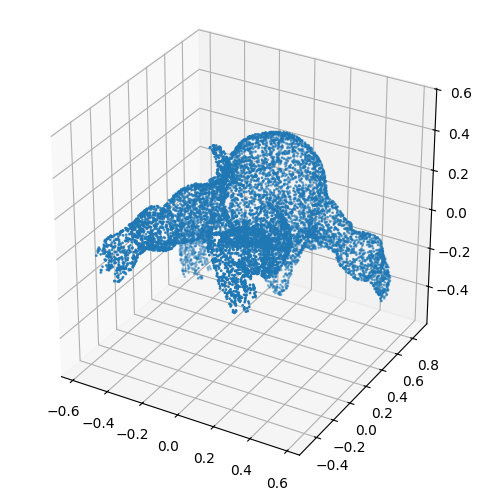

In [3]:
idx = np.random.choice(len(points), 10000, replace=False)
pts = points[idx]
x, y, z = pts[:,0], pts[:,1], pts[:,2]

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x, y, z, s=1)
ax.set_box_aspect([1, 1, 1])

plt.show()


## Defining the Model

In this cell we will define the SIREN model. This particular INR uses sine activations for nonlinearity and is supposed to capture more information given the underlying data when compared to a model that uses ReLU activations. This way, a good INR accuracy can be achieved with fewer neurons.

In [9]:
model = si.SIRENSDF(hidden_dim=64, num_hidden_layers=3)
model_loss = loss.Loss(lambda_surface=1, lambda_eikonal=0.1, lambda_normal=0, normal_present=False) # optional normal loss if normals contained in the pointcloud
optimizer = torch.optim.Adam(model.parameters())


## Model training



In [11]:
train(epochs=100, data=points, no_surface=1024, no_off_surface=2048, model=model, loss=model_loss, optimizer=optimizer)

Step 00000 | Loss 0.007901
Step 00001 | Loss 0.008362
Step 00002 | Loss 0.007836
Step 00003 | Loss 0.007745
Step 00004 | Loss 0.007336
Step 00005 | Loss 0.007950
Step 00006 | Loss 0.007305
Step 00007 | Loss 0.007683
Step 00008 | Loss 0.007484
Step 00009 | Loss 0.007705
Step 00010 | Loss 0.007340
Step 00011 | Loss 0.007517
Step 00012 | Loss 0.007096
Step 00013 | Loss 0.007332
Step 00014 | Loss 0.007013
Step 00015 | Loss 0.007304
Step 00016 | Loss 0.007395
Step 00017 | Loss 0.007593
Step 00018 | Loss 0.006976
Step 00019 | Loss 0.007839
Step 00020 | Loss 0.006639
Step 00021 | Loss 0.007403
Step 00022 | Loss 0.007439
Step 00023 | Loss 0.006906
Step 00024 | Loss 0.007012
Step 00025 | Loss 0.007263
Step 00026 | Loss 0.007025
Step 00027 | Loss 0.007152
Step 00028 | Loss 0.006975
Step 00029 | Loss 0.006971
Step 00030 | Loss 0.007073
Step 00031 | Loss 0.006776
Step 00032 | Loss 0.006957
Step 00033 | Loss 0.007554
Step 00034 | Loss 0.006726
Step 00035 | Loss 0.006965
Step 00036 | Loss 0.006561
S

In [16]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Sample a few surface points and check their SDF values
test_points = points[:10]  # First 10 points
test_tensor = torch.from_numpy(test_points).float().to(device)
with torch.no_grad():
    sdf_values = model(test_tensor)
print("SDF values for surface points:")
print(sdf_values)
print("Mean absolute SDF:", torch.abs(sdf_values).mean().item())

SDF values for surface points:
tensor([[-0.0264],
        [ 0.0055],
        [-0.0211],
        [ 0.0441],
        [ 0.0083],
        [ 0.0113],
        [ 0.0115],
        [ 0.0077],
        [-0.0008],
        [-0.0194]], device='cuda:0')
Mean absolute SDF: 0.015592020936310291
